In [97]:
import numpy as np
import pickle
from mpl_toolkits.axes_grid1 import ImageGrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from figure import * 
from post_processing_tool import * 

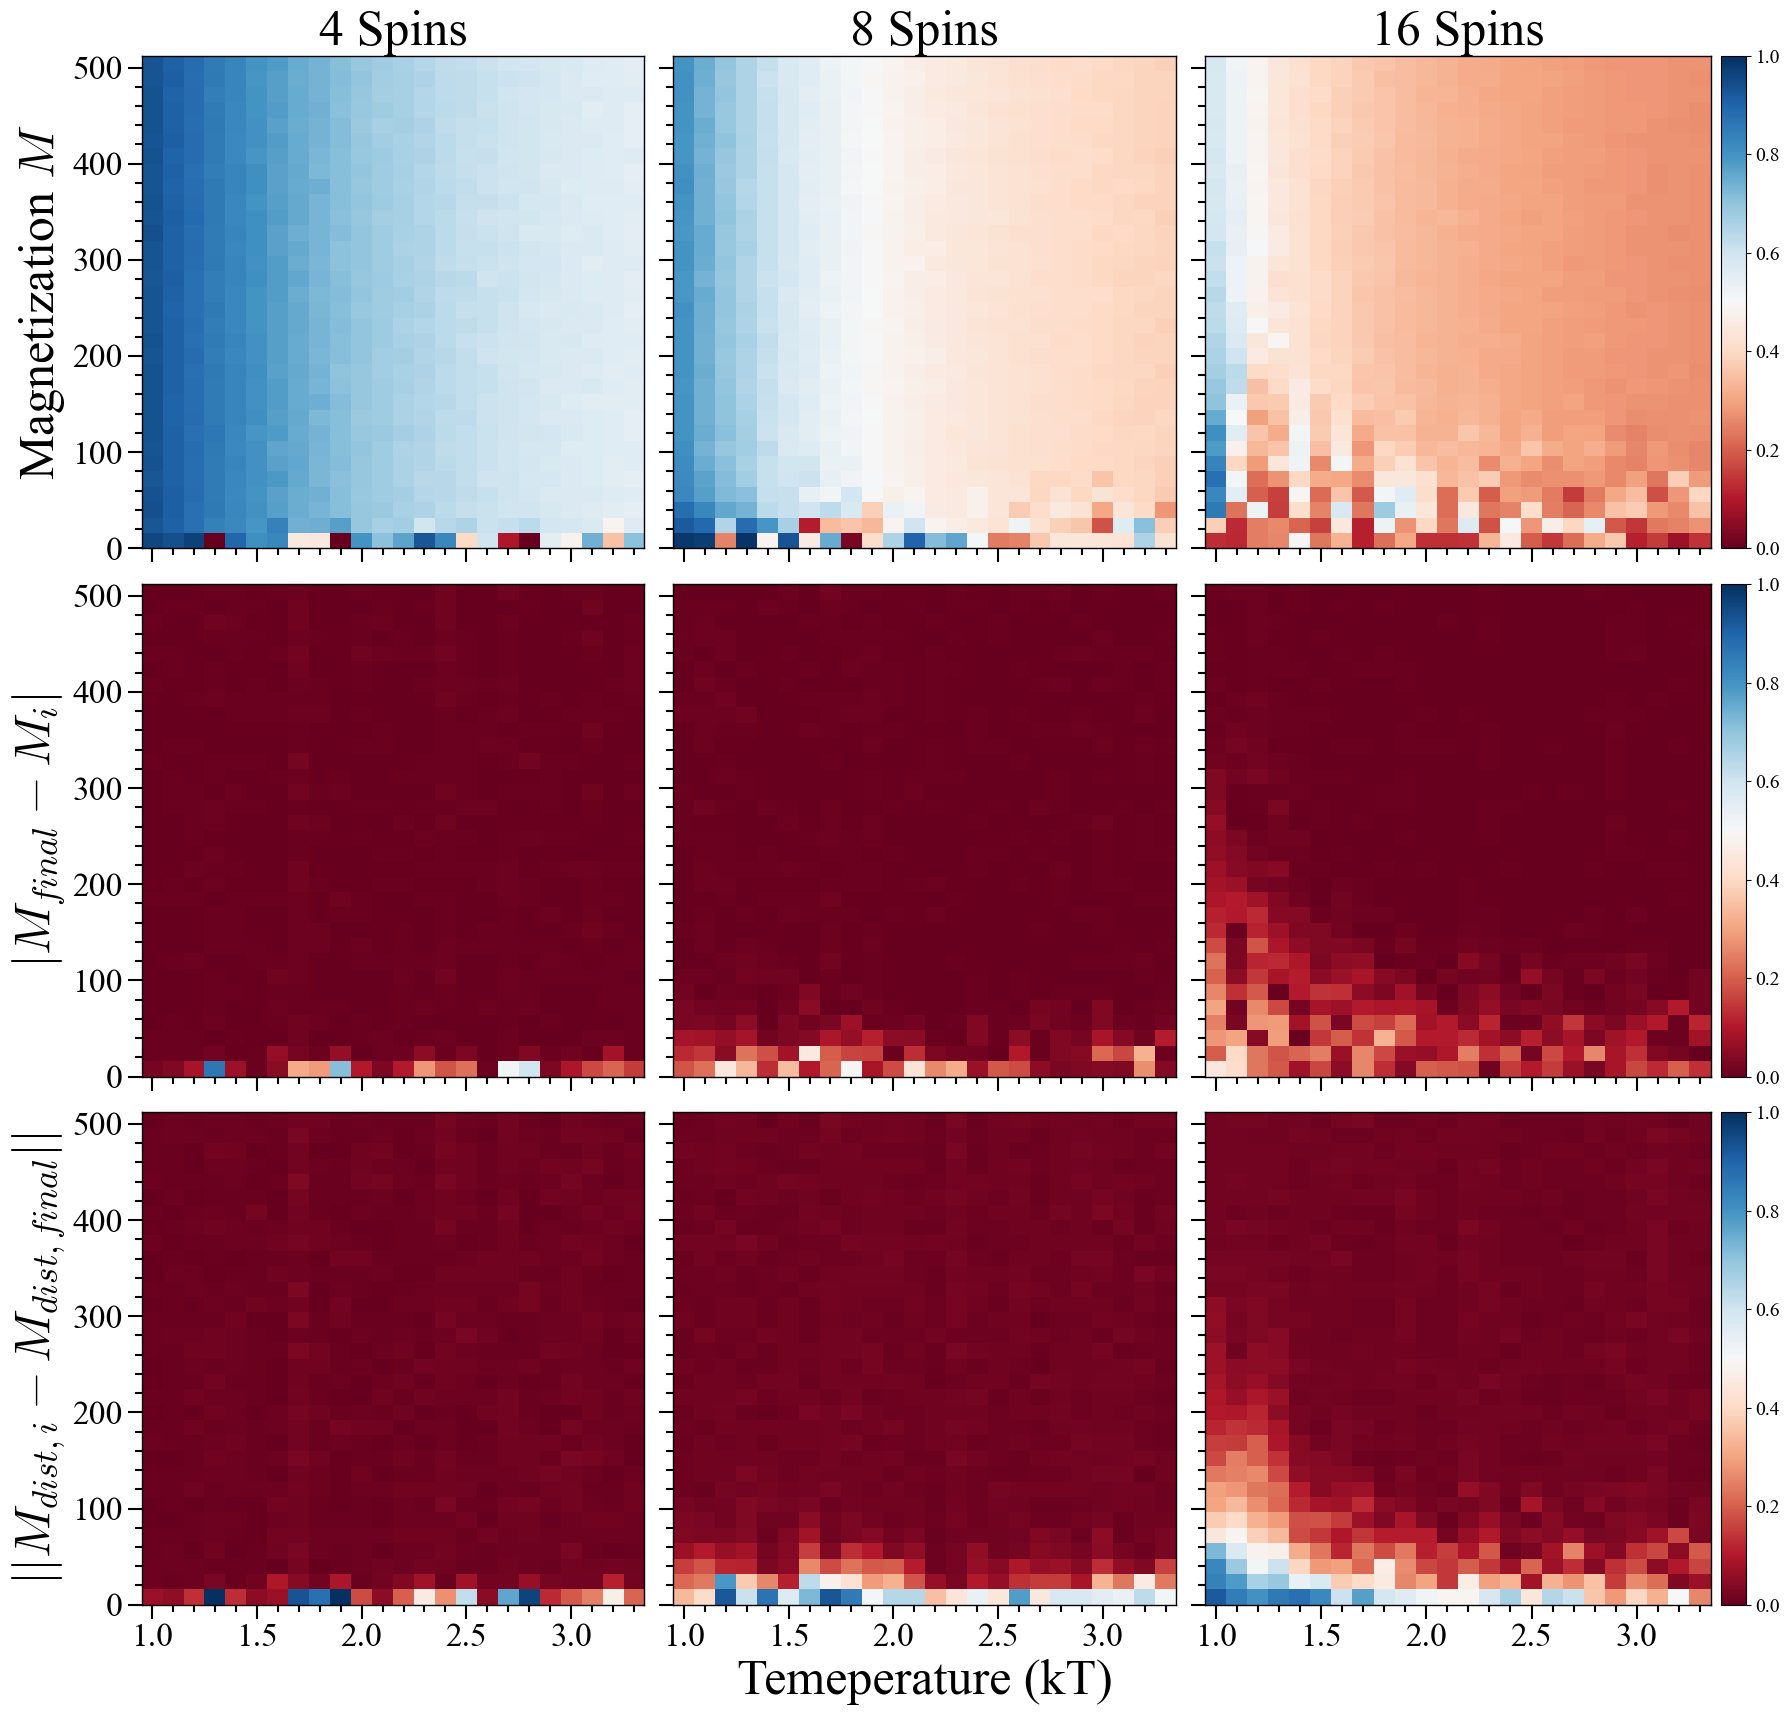

In [98]:
#### MC sweep to the stationary state ##### 
fig, axes = plt.subplots(3, 3, gridspec_kw={'width_ratios': [1, 1, 1/0.93]},sharex=True, sharey=True, figsize=(18,17.25))
Mag, Mag_res, State_res =[], [], []
plt.rcParams['mathtext.fontset'] ='cm'
fonts = {'family': 'Times new roman','weight': 'normal','size': 36}
directory = ["1_4spins/","2_8spins/","3_16spins/"]
for i in range(3):
    [Mag,Mag_res, State_res]=get_Mag_info(directory[i],2**(2+i))
    y, x = np.meshgrid(np.linspace(8, 504, 32), np.linspace(1.0, 3.3, 24))
    p1= axes[0,i].pcolormesh(x,y,Mag, cmap='RdBu', vmax=1, vmin=0)
    p2 = axes[1,i].pcolormesh(x,y,Mag_res, cmap='RdBu', vmax=1, vmin=0)
    p3 = axes[2,i].pcolormesh(x,y,State_res, cmap='RdBu', vmax=1, vmin=0)
    # axes[0,i].text(-0.1, 1.1, string.ascii_uppercase[i], transform=ax.transAxes, 
    #         size=20, weight='bold')
    ax_info = [axes[0,i], axes[1,i], axes[2,i]]
    p_info = [p1,p2,p3]
axes[0,0].set_title('4 Spins', fonts)
axes[0,1].set_title('8 Spins', fonts)
axes[0,2].set_title('16 Spins', fonts)
axes[0,0].set_ylabel('Magnetization $M$', fonts)
axes[1,0].set_ylabel('$|M_{final}-M_i|$', fonts)
axes[2,0].set_ylabel('$||M_{dist, i}-M_{dist,final}||$', fonts)
for i in range(3):    
    divider = make_axes_locatable(axes[i, 2])  # Use the last subplot in the row for positioning
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar=fig.colorbar(p_info[i], cax=cax)
    cbar.ax.tick_params(labelsize=14)
    labels = cbar.ax.get_yticklabels() +  cbar.ax.get_xticklabels() 
    [label.set_fontname('Times new roman') for label in labels]
    [label.set_weight('normal') for label in labels]
axes[2,1].set_xlabel('Temeperature (kT)', fonts)
for ax_row in axes:
    for ax in ax_row:
        ax.spines["top"].set_linewidth(standard)
        ax.spines["bottom"].set_linewidth(standard)
        ax.spines["right"].set_linewidth(standard)
        ax.spines["left"].set_linewidth(standard)
        ax.tick_params(axis='x', labelsize =24, direction='out', length=10, width=1.5, )
        ax.tick_params(axis='y', labelsize =24, direction='out', length=10, width=1.5, )
        labels = ax.get_yticklabels() + ax.get_xticklabels() 
        [label.set_fontname('Times new roman') for label in labels]
        [label.set_weight('normal') for label in labels]
        ax.minorticks_on()
        ax.tick_params(axis='x', which='minor', direction='out', length=5, width= 1.5)
        ax.tick_params(axis='y', which='minor', direction='out', length=5, width= 1.5)
plt.tight_layout()
plt.show()
# fig.savefig('./1D_case.png', dpi=300,bbox_inches='tight')    


In [102]:
#### final state ####
m4,m8,m16=[],[],[]
for i in np.round(np.arange(1.0, 3.4, 0.1),1):
    with open("1_4spins/"+str(i)+"/4@"+str(i)+"w_512", "rb") as f: 
        result = pickle.load(f)
    m4.append(result[-1])
    with open("2_8spins/"+str(i)+"/8@"+str(i)+"w_512", "rb") as f: 
        result = pickle.load(f)
    m8.append(result[-1])
    with open("3_16spins/"+str(i)+"/16@"+str(i)+"w_512", "rb") as f: 
        result = pickle.load(f)
    m16.append(result[-1])

In [103]:
##### analytic solution based on Boltzmann factor #####
temps = np.arange(1.0, 3.4, 0.1)
Mag_4=[]
possible_state, energy, mag = get_info_1D(4)
for temp in temps: 
  beta = 1/temp
  exponent = np.array([np.exp(-beta*i) for i in energy])
  Mag_4.append(np.sum(np.dot(exponent,mag))/np.sum(exponent))

Mag_8=[]
possible_state, energy, mag = get_info_1D(8)
for temp in temps: 
  beta = 1/temp
  exponent = np.array([np.exp(-beta*i) for i in energy])
  Mag_8.append(np.sum(np.dot(exponent,mag))/np.sum(exponent))

Mag_16=[]
possible_state, energy, mag = get_info_1D(16)
for temp in temps: 
  beta = 1/temp
  exponent = np.array([np.exp(-beta*i) for i in energy])
  Mag_16.append(np.sum(np.dot(exponent,mag))/np.sum(exponent))

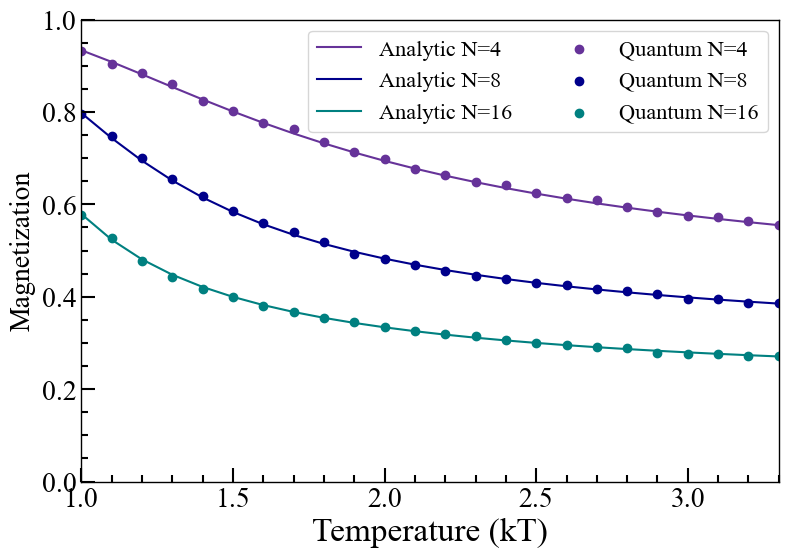

In [104]:
fig, ax = plt.subplots(figsize=(9,6))
color =['rebeccapurple', 'darkblue', 'teal', 'turquoise', 'gold','orange','darkgoldenrod','darkred', 'dimgrey']
ax.plot(np.arange(1.0, 3.4, 0.1), Mag_4, color=color[0], label='Analytic N=4')
ax.plot(np.arange(1.0, 3.4, 0.1), Mag_8, color=color[1], label='Analytic N=8')
ax.plot(np.arange(1.0, 3.4, 0.1), Mag_16, color=color[2], label='Analytic N=16')
ax.scatter(np.arange(1.0, 3.4, 0.1), m4, color=color[0], label='Quantum N=4')
ax.scatter(np.arange(1.0, 3.4, 0.1), m8, color=color[1], label='Quantum N=8')
ax.scatter(np.arange(1.0, 3.4, 0.1), m16, color=color[2], label='Quantum N=16')
ax.legend(prop = font3)
ax.minorticks_on()
ax.tick_params(axis='x', which='minor', direction='in', length=5, width= 1.5)
ax.tick_params(axis='y', which='minor', direction='in', length=5, width= 1.5)
ax.legend(prop = font3, ncol=2)
ax.spines["top"].set_linewidth(standard)
ax.spines["bottom"].set_linewidth(standard)
ax.spines["right"].set_linewidth(standard)
ax.spines["left"].set_linewidth(standard)
labels = ax.get_yticklabels() + ax.get_xticklabels() 
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
ax.minorticks_on()
ax.tick_params(axis='x', labelsize =20, direction='in', length=10, width=1.5, )
ax.tick_params(axis='y', labelsize =20, direction='in', length=10, width=1.5, )
ax.set_ylim(0,1)
ax.set_xlabel('Temperature (kT)', font1)
ax.set_ylabel('Magnetization', font2)
ax.set_xlim(1,3.3)
fig.savefig('./1D_compare.png', dpi=300,bbox_inches='tight')   
plt.show()
